In [11]:
# INDEX-WISE PARSING (done using)

import json

def reconstruct_by_index(file_path):
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        
        if not data:
            return ""

        # 1. Find the maximum index to determine the array size
        # This is similar to sizing a vector in C++
        max_idx = max(item['idx'] for item in data)
        
        # 2. Create a list (array) filled with empty strings
        # Size is max_idx + 1 to accommodate 0-based indexing
        text_array = [""] * (max_idx + 1)

        # 3. Place each glyph directly into its corresponding index
        for item in data:
            idx = item['idx']
            text_array[idx] = item['char']

        # 4. Join the array into a single string
        return "".join(text_array)

    except (FileNotFoundError, json.JSONDecodeError) as e:
        return f"Error: {e}"

# --- Usage ---
filename = '0.json'
print(reconstruct_by_index(filename))

Error: [Errno 2] No such file or directory: '0.json'


In [19]:
# CENTROID-BASED PARSING

import json

class TextReconstructor:
    def __init__(self, json_data):
        self.data = json_data

    def _get_center_y(self, bbox):
        # bbox format assumed: [x_min, y_min, x_max, y_max]
        _, y_min, _, y_max = bbox
        return (y_min + y_max) / 2

    def _boxes_overlap_vertically(self, bbox1, bbox2, threshold=0.5):
        """
        Check if two boxes overlap vertically by a certain percentage.
        This handles variable heights (e.g., a tall char next to a short one).
        """
        y1_min, y1_max = bbox1[1], bbox1[3]
        y2_min, y2_max = bbox2[1], bbox2[3]

        # Calculate intersection height
        intersection_min = max(y1_min, y2_min)
        intersection_max = min(y1_max, y2_max)
        intersection_h = max(0, intersection_max - intersection_min)

        # Height of the smaller box (to be lenient with short chars)
        h1 = y1_max - y1_min
        h2 = y2_max - y2_min
        min_height = min(h1, h2)
        
        if min_height == 0: return False

        # If intersection covers > 50% of the smaller box's height, they are on the same line
        return (intersection_h / min_height) > threshold

    def reconstruct(self):
        # 1. Sort all items by Y-center initially to process top-to-bottom
        sorted_data = sorted(self.data, key=lambda x: self._get_center_y(x['bbox']))

        lines = []  # Will store lists of items: [ [item1, item2], [item3, item4] ]

        for item in sorted_data:
            placed = False
            
            # Try to fit this item into an existing line
            for line in lines:
                # We check overlap with the LAST item added to that line
                # (Or you could check the average Y of the line)
                reference_item = line[-1]
                
                if self._boxes_overlap_vertically(item['bbox'], reference_item['bbox']):
                    line.append(item)
                    placed = True
                    break
            
            # If it didn't fit in any existing line, start a new one
            if not placed:
                lines.append([item])

        # 2. Sort lines vertically (just to be safe)
        # We use the average Y-center of the line to sort the lines themselves
        def get_line_avg_y(line_items):
            return sum(self._get_center_y(i['bbox']) for i in line_items) / len(line_items)
        
        lines.sort(key=get_line_avg_y)

        # 3. Sort items WITHIN each line horizontally (by x_min)
        final_output_lines = []
        for line in lines:
            # Sort by x_min (bbox[0])
            line.sort(key=lambda x: x['bbox'][0])
            
            # Join the glyphs
            line_text = "".join(item['char'] for item in line)
            final_output_lines.append(line_text)

        # 4. Join all lines with a newline character
        return "\n".join(final_output_lines)

# --- Usage ---
def get_text3(json_path):
    with open(json_path, 'r', encoding='utf-8') as f:
        raw_json = json.load(f)
    return TextReconstructor(raw_json).reconstruct().replace('\n', '')

# reconstructor = TextReconstructor(raw_json)
# result = reconstructor.reconstruct()

# print("--- Reconstructed Text ---")
# print(result)

print(get_text3('etc/0.json'))

KeyError: 'char'

In [ ]:
# PREPARE SENTENCE DATA
import os

# Directory containing the JSON files
input_dir = 'data/jsons_new/'
output_file = 'data/strings.txt'

# List to store reconstructed strings
reconstructed_strings = []

# Iterate over all files in the directory
for file_name in os.listdir(input_dir):
    file_path = os.path.join(input_dir, file_name)
    
    # Ensure the file is a JSON file
    if file_name.endswith('.json'):
        reconstructed_text = reconstruct_by_index(file_path)
        reconstructed_strings.append(reconstructed_text)

# Save all reconstructed strings into the output file
with open(output_file, 'w', encoding='utf-8') as f:
    f.write("\n".join(reconstructed_strings))

print(f"Reconstructed strings saved to {output_file}")

Reconstructed strings saved to data/strings.txt


In [ ]:
import json
from ultralytics import YOLO

image_path = "data/imgs/0.jpg"

def inference_det(image_path):

    model = YOLO("models/yolo_det.pt")
    output_json = "results_det.json"
    results = model(image_path, conf=0.25)
    detections = []

    for r in results:
        boxes = r.boxes.xyxy.cpu().numpy()

        for x1, y1, x2, y2 in boxes:
            detections.append({
                "bbox": [
                    float(x1),
                    float(y1),
                    float(x2),
                    float(y2)
                ]
            })
    with open(output_json, "w", encoding="utf-8") as f:
        json.dump(detections, f, indent=2)

inference_det(image_path)


image 1/1 /mnt/windows/Users/Aditya Bhandari/Desktop/code/GitHub/Inscription-character-deciphering-for-Brahmi-script/data/imgs/0.jpg: 160x640 49 cs, 368.7ms
Speed: 2.3ms preprocess, 368.7ms inference, 5.9ms postprocess per image at shape (1, 3, 160, 640)



image 1/1 /mnt/windows/Users/Aditya Bhandari/Desktop/code/GitHub/Inscription-character-deciphering-for-Brahmi-script/data/yolo_format_det/images/val/999.jpg: 160x640 60 cs, 414.6ms
Speed: 23.8ms preprocess, 414.6ms inference, 12.4ms postprocess per image at shape (1, 3, 160, 640)


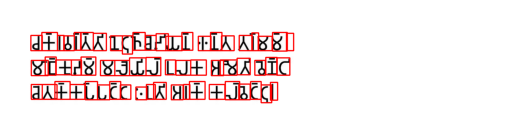

In [8]:
import cv2
import matplotlib.pyplot as plt

results = model(
    source="data/yolo_format_det/images/val/999.jpg",
    conf=0.25,
    iou=0.45,
    device='cpu'
)

# Load the image
image_path = "data/yolo_format_det/images/val/999.jpg"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Draw bounding boxes on the image
for box in results[0].boxes.xyxy:
    x_min, y_min, x_max, y_max = map(int, box)
    cv2.rectangle(image, (x_min, y_min), (x_max, y_max), (255, 0, 0), 2)

# Display the image
plt.imshow(image)
plt.axis("off")
plt.show()

In [3]:
import json
from pathlib import Path
from PIL import Image

# Paths
imgs_dir = Path("data/imgs/engr")
jsons_dir = Path("data/jsons/new")
out_dir = Path("data/chars/chars_engr")

out_dir.mkdir(parents=True, exist_ok=True)

def safe_char_name(ch: str) -> str:
    # Use Unicode codepoints for filesystem safety
    return "_".join(f"U+{ord(c):04X}" for c in ch)

for json_path in jsons_dir.glob("*.json"):
    # Find corresponding image by stem
    img_path = None
    for ext in (".png", ".jpg", ".jpeg", ".webp"):
        candidate = imgs_dir / (json_path.stem + ext)
        if candidate.exists():
            img_path = candidate
            break

    if img_path is None:
        continue

    with open(json_path, "r", encoding="utf-8") as f:
        annotations = json.load(f)

    img = Image.open(img_path).convert("RGB")

    for ann in annotations:
        char = ann["glyph"]
        x1, y1, x2, y2 = ann["bbox"]

        # Ensure integer bounding box
        box = (int(x1), int(y1), int(x2), int(y2))
        crop = img.crop(box)

        char_dir = out_dir / safe_char_name(char)
        char_dir.mkdir(parents=True, exist_ok=True)

        idx = ann.get("idx", 0)
        out_path = char_dir / f"{json_path.stem}_{idx}.png"
        crop.save(out_path)

In [4]:
# DECODING

def decode_char_folder(name: str) -> str:
    """
    Convert folder name like:
    'U+1101C_U+11038' -> '𑀜𑀸'
    """
    chars = []
    for part in name.split("_"):
        if not part.startswith("U+"):
            raise ValueError(f"Invalid format: {part}")
        codepoint = int(part[2:], 16)
        chars.append(chr(codepoint))
    return "".join(chars)


In [4]:
# T-V SPLIT FOR CHARS

import os
import random
import shutil

SRC_DIR = "data/chars/engr/"
DST_DIR = "data/chars/engr_split/"

TRAIN_RATIO = 0.8
SEED = 42
IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

random.seed(SEED)

def is_image(fname):
    return os.path.splitext(fname)[1].lower() in IMAGE_EXTS

for split in ["train", "val"]:
    os.makedirs(os.path.join(DST_DIR, split), exist_ok=True)

classes = sorted(os.listdir(SRC_DIR))

for cls in classes:
    cls_path = os.path.join(SRC_DIR, cls)
    if not os.path.isdir(cls_path):
        continue

    images = [
        f for f in os.listdir(cls_path)
        if is_image(f)
    ]

    if len(images) < 2:
        print(f"Skipping {cls}: not enough images")
        continue

    random.shuffle(images)
    split_idx = int(len(images) * TRAIN_RATIO)

    train_imgs = images[:split_idx]
    val_imgs   = images[split_idx:]

    for split, img_list in [("train", train_imgs), ("val", val_imgs)]:
        dst_cls_dir = os.path.join(DST_DIR, split, cls)
        os.makedirs(dst_cls_dir, exist_ok=True)

        for img in img_list:
            src = os.path.join(cls_path, img)
            dst = os.path.join(dst_cls_dir, img)
            shutil.copy2(src, dst)

    print(f"{cls}: {len(train_imgs)} train / {len(val_imgs)} val")


U+11005: 656 train / 164 val
U+11006: 133 train / 34 val
U+11007: 276 train / 69 val
U+11008: 331 train / 83 val
U+11009: 163 train / 41 val
U+1100A: 82 train / 21 val
U+1100F: 300 train / 76 val
U+11010: 4 train / 2 val
U+11011: 80 train / 20 val
U+11013: 2185 train / 547 val
U+11013_U+11038: 241 train / 61 val
U+11013_U+1103A: 509 train / 128 val
U+11013_U+1103B: 5 train / 2 val
U+11013_U+1103C: 876 train / 219 val
U+11013_U+1103D: 31 train / 8 val
U+11013_U+11042: 8 train / 2 val
U+11013_U+11043: 322 train / 81 val
U+11013_U+11044: 150 train / 38 val
U+11013_U+11045: 1 train / 1 val
U+11013_U+11046: 1178 train / 295 val
U+11017_U+11046: 708 train / 178 val
U+11018: 184 train / 47 val
U+11018_U+11038: 218 train / 55 val
U+11018_U+1103A: 296 train / 74 val
U+11018_U+1103B: 4 train / 1 val
U+11018_U+1103C: 148 train / 37 val
U+11018_U+1103D: 9 train / 3 val
U+11018_U+11042: 396 train / 99 val
U+11018_U+11043: 52 train / 13 val
U+11018_U+11044: 5 train / 2 val
U+11018_U+11046: 125 train

In [5]:
import torch
import torch.nn as nn
from torchvision.models import mobilenet_v2
from torchvision import transforms
from PIL import Image

device = "cuda" if torch.cuda.is_available() else "cpu"

ckpt = torch.load("models/mobilenet_brahmi_classifier.pt", map_location=device)
classes = ckpt["classes"]
num_classes = len(classes)

model = mobilenet_v2(pretrained=False)
model.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(model.last_channel, num_classes)
)

model.load_state_dict(ckpt["model_state"])
model.eval()
model.to(device)


/mnt/windows/Users/Aditya Bhandari/Desktop/code/GitHub/Inscription-character-deciphering-for-Brahmi-script/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/mnt/windows/Users/Aditya Bhandari/Desktop/code/GitHub/Inscription-character-deciphering-for-Brahmi-script/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [6]:
IMG_SIZE = 224

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [8]:
img = Image.open("/mnt/windows/Users/Aditya Bhandari/Desktop/code/GitHub/Inscription-character-deciphering-for-Brahmi-script/data/chars_split/val/U+1100F/152_7.png").convert("RGB")
x = transform(img).unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(x)
    probs = torch.softmax(logits, dim=1)
    pred_idx = probs.argmax(dim=1).item()
    confidence = probs[0, pred_idx].item()

print("Predicted class:", classes[pred_idx])
print("Confidence:", confidence)


Predicted class: U+1100F
Confidence: 0.9999996423721313


In [1]:
import json
from ultralytics import YOLO
import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.models import mobilenet_v2
from PIL import Image

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
model_det = YOLO("models/yolo_det.pt")

ckpt = torch.load("models/mobilenet_brahmi_classifier.pt", map_location=DEVICE)
classes = ckpt["classes"]
model_clf = mobilenet_v2(pretrained=False)
model_clf.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(model_clf.last_channel, len(classes))
)
model_clf.load_state_dict(ckpt["model_state"])
model_clf.to(DEVICE)
model_clf.eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

/mnt/windows/Users/Aditya Bhandari/Desktop/code/GitHub/Inscription-character-deciphering-for-Brahmi-script/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/mnt/windows/Users/Aditya Bhandari/Desktop/code/GitHub/Inscription-character-deciphering-for-Brahmi-script/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [5]:
@torch.no_grad()
def classify_detections(image_path, bbox_json_path):
    output_json_path = image_path.split(".")[0] + "_res_clf.json"
    image = Image.open(image_path).convert("RGB")

    with open(bbox_json_path, "r") as f:
        detections = json.load(f)

    results = []

    for det in detections:
        x1, y1, x2, y2 = map(int, det["bbox"])

        crop = image.crop((x1, y1, x2, y2))
        x = transform(crop).unsqueeze(0).to(DEVICE)

        logits = model_clf(x)
        pred_idx = logits.argmax(dim=1).item()
        pred_class = classes[pred_idx]

        results.append({
            "char": decode_char_folder(pred_class),
            "bbox": det["bbox"]
        })

    with open(output_json_path, "w", encoding="utf-8") as f:
        json.dump(results, f, ensure_ascii=False, indent=2)

# '''
classify_detections(
    image_path="data/imgs/0.jpg",
    bbox_json_path="results_det.json"
)
# '''





In [13]:
get_text3('data/imgs/0_res_clf.json')

'𑀫𑀗𑁆𑀓𑁃𑀬𑀽𑀭𑁆𑀦𑁂𑀝𑀼𑀫𑀸𑀭𑀦𑁆𑀘𑁂𑀬𑁆𑀢𑀢𑀸𑀦𑀫𑁆𑁇𑀧𑀼𑀓𑀴𑀽𑀭𑁆𑀘𑀫𑀡𑀫𑀼𑀦𑀺𑀯𑀭𑁆𑀓𑁆𑀓𑀼𑀇𑀧𑁆𑀧𑀴𑁆𑀴𑀺𑀅𑀫𑀡𑀧𑁆𑀧𑀸𑀴𑀺𑁇𑀅𑀭𑀫𑁆𑀯𑁂𑀮𑁆𑀓𑁇'